In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load the dataset

df = pd.read_csv("/content/sonardataset.csv")

# Display first five rows

df

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [ ]:
# Display number of rows and columns

print("Dataset Shape:", df.shape)

# Display column names

print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information

print("\nDataset Information:")
df.info()

Dataset Shape: (208, 61)

Column Names:
['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10', 'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19', 'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28', 'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37', 'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46', 'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55', 'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'Y']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-nu

In [ ]:
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
# Check missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64


In [ ]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 0


In [ ]:
# Identify numerical columns

numeric_columns = df.select_dtypes(
    include=np.number
).columns

# Fill missing numerical values with median

for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

In [ ]:
print(
    "Missing values after preprocessing:",
    df.isnull().sum().sum()
)

Missing values after preprocessing: 0


In [ ]:
# Check duplicate rows

print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


In [ ]:
# Remove duplicate records

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (208, 61)


In [ ]:
# Display class distribution

print(df.iloc[:, -1].value_counts())

Y
M    111
R     97
Name: count, dtype: int64


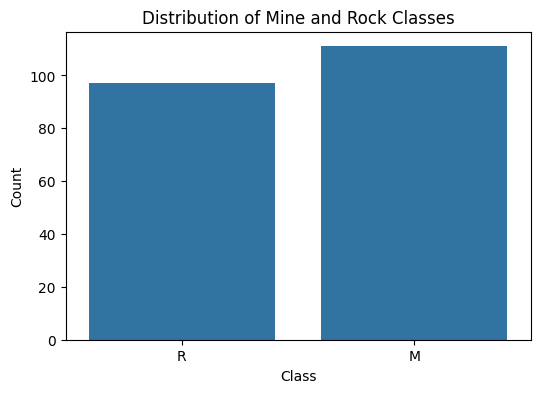

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=df.iloc[:, -1]
)

plt.title("Distribution of Mine and Rock Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
# Separate input features and target

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (208, 60)
Target shape: (208,)


In [ ]:
# Convert target labels into numerical values

y = y.map({
    'M': 1,
    'R': 0
})

print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: Y, dtype: int64


In [ ]:
print(y.value_counts())

Y
1    111
0     97
Name: count, dtype: int64


In [ ]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (166, 60)
Testing data: (42, 60)


In [ ]:
# Create scaler

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (166, 60)
Scaled testing data shape: (42, 60)


In [ ]:
# Create basic ANN model

model = Sequential([

    # Input + hidden layer
    Dense(
        32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),

    # Output layer
    Dense(
        1,
        activation='sigmoid'
    )
])

# Display model architecture

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the ANN model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5000 - loss: 0.8475 - val_accuracy: 0.6765 - val_loss: 0.6304
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5985 - loss: 0.6878 - val_accuracy: 0.7059 - val_loss: 0.5633
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6742 - loss: 0.5882 - val_accuracy: 0.7647 - val_loss: 0.5159
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7348 - loss: 0.5271 - val_accuracy: 0.7941 - val_loss: 0.4838
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7273 - loss: 0.4889 - val_accuracy: 0.7941 - val_loss: 0.4599
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7424 - loss: 0.4613 - val_accuracy: 0.8235 - val_loss: 0.4409
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.4380 - val_accuracy: 0.8235 - val_loss: 0.4249
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7576 - loss: 0.4170 - val_accuracy: 0.8529 - val_loss: 0.4114
Epoc

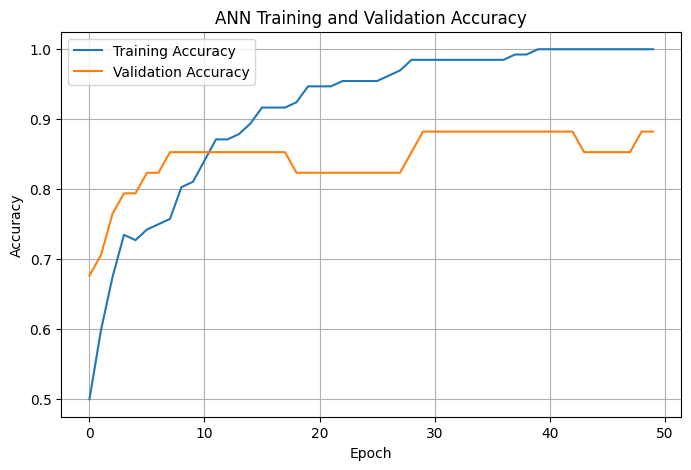

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

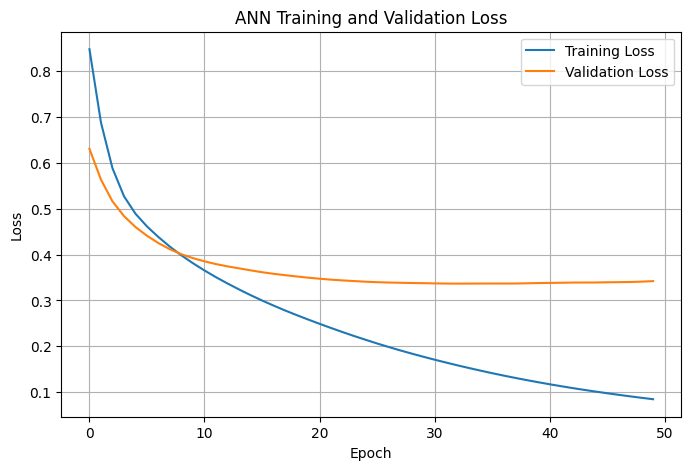

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Predict probabilities

y_pred_probability = model.predict(
    X_test_scaled
)

# Convert probabilities into classes

y_pred = (
    y_pred_probability > 0.5
).astype(int).flatten()

print(y_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
[0 1 1 1 0 0 0 1 0 0]


In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Basic ANN Performance")
print("---------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Basic ANN Performance
---------------------
Accuracy : 0.9523809523809523
Precision: 0.9545454545454546
Recall   : 0.9545454545454546
F1 Score : 0.9545454545454546


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Rock', 'Mine']
    )
)

              precision    recall  f1-score   support

        Rock       0.95      0.95      0.95        20
        Mine       0.95      0.95      0.95        22

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42



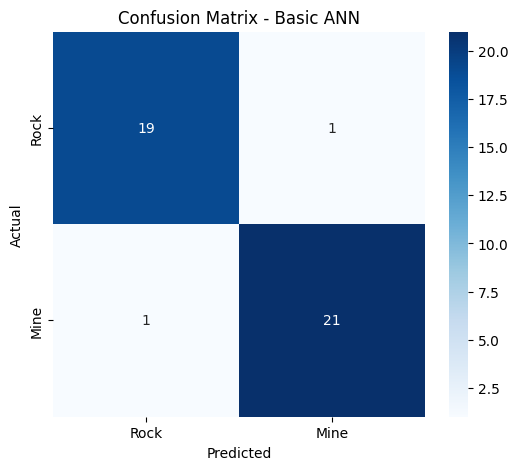

In [ ]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rock', 'Mine'],
    yticklabels=['Rock', 'Mine']
)

plt.title("Confusion Matrix - Basic ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
def build_ann(
    hidden_layers=1,
    neurons=32,
    activation='relu',
    learning_rate=0.001,
    dropout_rate=0.0
):

    model = Sequential()

    # First hidden layer
    model.add(
        Dense(
            neurons,
            activation=activation,
            input_shape=(X_train_scaled.shape[1],)
        )
    )

    # Additional hidden layers
    for _ in range(hidden_layers - 1):

        model.add(
            Dense(
                neurons,
                activation=activation
            )
        )

        # Optional dropout
        if dropout_rate > 0:
            model.add(
                Dropout(dropout_rate)
            )

    # Output layer
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    # Compile
    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Hyperparameter combinations

configurations = [
    {
        'hidden_layers': 1,
        'neurons': 16,
        'activation': 'relu',
        'learning_rate': 0.001
    },

    {
        'hidden_layers': 1,
        'neurons': 32,
        'activation': 'relu',
        'learning_rate': 0.001
    },

    {
        'hidden_layers': 2,
        'neurons': 32,
        'activation': 'relu',
        'learning_rate': 0.001
    },

    {
        'hidden_layers': 2,
        'neurons': 64,
        'activation': 'relu',
        'learning_rate': 0.001
    },

    {
        'hidden_layers': 2,
        'neurons': 32,
        'activation': 'tanh',
        'learning_rate': 0.001
    },

    {
        'hidden_layers': 2,
        'neurons': 32,
        'activation': 'relu',
        'learning_rate': 0.0005
    }
]

In [ ]:
results = []

for config in configurations:

    print(
        "\nTesting configuration:",
        config
    )

    # Build model
    tuning_model = build_ann(
        hidden_layers=config['hidden_layers'],
        neurons=config['neurons'],
        activation=config['activation'],
        learning_rate=config['learning_rate']
    )

    # Train model
    tuning_model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.20,
        verbose=0
    )

    # Predict
    predictions_probability = tuning_model.predict(
        X_test_scaled,
        verbose=0
    )

    predictions = (
        predictions_probability > 0.5
    ).astype(int).flatten()

    # Calculate metrics
    acc = accuracy_score(
        y_test,
        predictions
    )

    prec = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        'Hidden Layers': config['hidden_layers'],
        'Neurons': config['neurons'],
        'Activation': config['activation'],
        'Learning Rate': config['learning_rate'],
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1_value
    })


Testing configuration: {'hidden_layers': 1, 'neurons': 16, 'activation': 'relu', 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing configuration: {'hidden_layers': 1, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing configuration: {'hidden_layers': 2, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.001}

Testing configuration: {'hidden_layers': 2, 'neurons': 64, 'activation': 'relu', 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing configuration: {'hidden_layers': 2, 'neurons': 32, 'activation': 'tanh', 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing configuration: {'hidden_layers': 2, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.0005}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
results_df = pd.DataFrame(results)

results_df

,Hidden Layers,Neurons,Activation,Learning Rate,Accuracy,Precision,Recall,F1 Score
0,1,16,relu,0.0010,0.904762,0.909091,0.909091,0.909091
1,1,32,relu,0.0010,0.904762,0.875000,0.954545,0.913043
2,2,32,relu,0.0010,0.904762,0.875000,0.954545,0.913043
3,2,64,relu,0.0010,0.952381,0.916667,1.000000,0.956522
4,2,32,tanh,0.0010,0.833333,0.857143,0.818182,0.837209
5,2,32,relu,0.0005,0.928571,0.880000,1.000000,0.936170


In [ ]:
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Hidden Layers,Neurons,Activation,Learning Rate,Accuracy,Precision,Recall,F1 Score
3,2,64,relu,0.0010,0.952381,0.916667,1.000000,0.956522
5,2,32,relu,0.0005,0.928571,0.880000,1.000000,0.936170
2,2,32,relu,0.0010,0.904762,0.875000,0.954545,0.913043
1,1,32,relu,0.0010,0.904762,0.875000,0.954545,0.913043
0,1,16,relu,0.0010,0.904762,0.909091,0.909091,0.909091
4,2,32,tanh,0.0010,0.833333,0.857143,0.818182,0.837209


In [ ]:
best_result = results_df.loc[
    results_df['F1 Score'].idxmax()
]

print("Best Configuration:")
print(best_result)

Best Configuration:
Hidden Layers           2
Neurons                64
Activation           relu
Learning Rate       0.001
Accuracy         0.952381
Precision        0.916667
Recall                1.0
F1 Score         0.956522
Name: 3, dtype: object


In [ ]:
best_model = build_ann(
    hidden_layers=int(
        best_result['Hidden Layers']
    ),
    neurons=int(
        best_result['Neurons']
    ),
    activation=best_result['Activation'],
    learning_rate=best_result['Learning Rate']
)

best_history = best_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5000 - loss: 0.7569 - val_accuracy: 0.5588 - val_loss: 0.7020
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7348 - loss: 0.5785 - val_accuracy: 0.7941 - val_loss: 0.5806
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7879 - loss: 0.4898 - val_accuracy: 0.8529 - val_loss: 0.5138
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8561 - loss: 0.4244 - val_accuracy: 0.8824 - val_loss: 0.4672
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8788 - loss: 0.3706 - val_accuracy: 0.8824 - val_loss: 0.4311
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9091 - loss: 0.3260 - val_accuracy: 0.8529 - val_loss: 0.4045
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9394 - loss: 0.2862 - val_accuracy: 0.8529 - val_loss: 0.3870
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9773 - loss: 0.2504 - val_accuracy: 0.8529 - val_loss: 0.3760
Epoch 9/50
9/9

In [ ]:
# Predict using tuned model

tuned_probability = best_model.predict(
    X_test_scaled
)

tuned_prediction = (
    tuned_probability > 0.5
).astype(int).flatten()

# Metrics

tuned_accuracy = accuracy_score(
    y_test,
    tuned_prediction
)

tuned_precision = precision_score(
    y_test,
    tuned_prediction
)

tuned_recall = recall_score(
    y_test,
    tuned_prediction
)

tuned_f1 = f1_score(
    y_test,
    tuned_prediction
)

print("Tuned ANN Performance")
print("----------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Tuned ANN Performance
----------------------
Accuracy : 0.9047619047619048
Precision: 0.875
Recall   : 0.9545454545454546
F1 Score : 0.9130434782608695


In [ ]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Basic ANN': [
        accuracy,
        precision,
        recall,
        f1
    ],

    'Tuned ANN': [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison

,Metric,Basic ANN,Tuned ANN
0,Accuracy,0.952381,0.904762
1,Precision,0.954545,0.875000
2,Recall,0.954545,0.954545
3,F1 Score,0.954545,0.913043


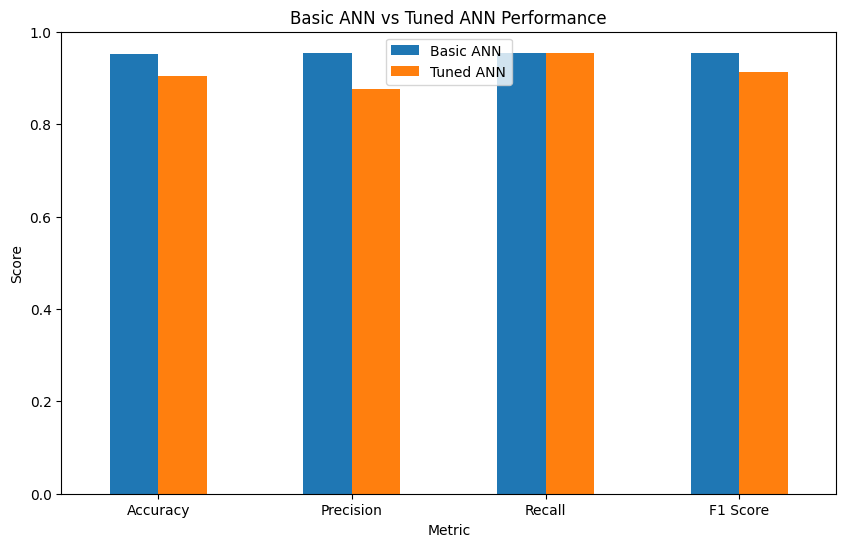

In [ ]:
comparison_plot = comparison.set_index(
    'Metric'
)

comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    "Basic ANN vs Tuned ANN Performance"
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.show()

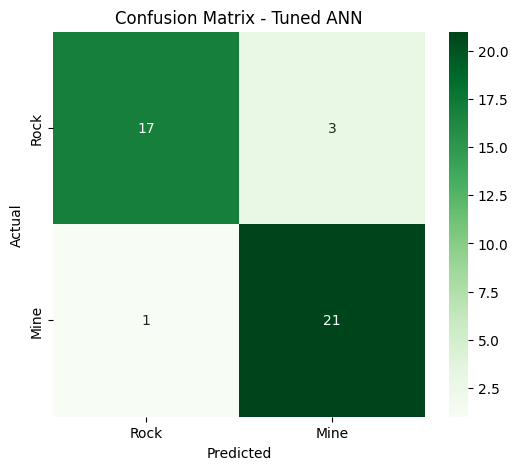

In [ ]:
cm_tuned = confusion_matrix(
    y_test,
    tuned_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Rock', 'Mine'],
    yticklabels=['Rock', 'Mine']
)

plt.title("Confusion Matrix - Tuned ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        tuned_prediction,
        target_names=['Rock', 'Mine']
    )
)

              precision    recall  f1-score   support

        Rock       0.94      0.85      0.89        20
        Mine       0.88      0.95      0.91        22

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/sonardataset.csv")
# Display first five rows
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
# Display number of rows and columns

print("Shape of dataset:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

Shape of dataset: (208, 61)

Column Names:
Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19',
       'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28',
       'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37',
       'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46',
       'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55',
       'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'Y'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-nu

In [ ]:
# Statistical summary

df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [ ]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64

Total missing values: 0


In [ ]:
# Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
target_column = df.columns[-1]
print("Target column:", target_column)
# Count classes
print(df[target_column].value_counts())

Target column: Y
Y
M    111
R     97
Name: count, dtype: int64


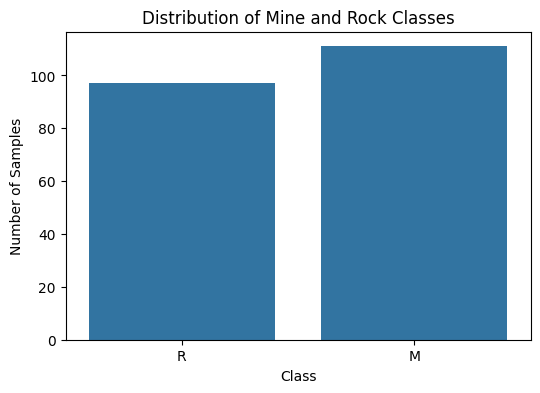

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=df[target_column])

plt.title("Distribution of Mine and Rock Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
# Check whether missing values exist

if df.isnull().sum().sum() > 0:

    # Fill numerical missing values with median
    numerical_columns = df.select_dtypes(include=np.number).columns

    df[numerical_columns] = df[numerical_columns].fillna(
        df[numerical_columns].median()
    )

    print("Missing values filled successfully.")

else:
    print("No missing values found.")

No missing values found.


In [ ]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (208, 61)


In [ ]:
# Separate input features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (208, 60)
Target shape: (208,)


In [ ]:
# Convert target labels into numerical values

y = y.map({
    "M": 1,
    "R": 0
})

print(y.value_counts())

# If your dataset uses lowercase values, use:
# y = y.astype(str).str.upper()

# y = y.map({
#     "M": 1,
#     "R": 0
# })

Y
1    111
0     97
Name: count, dtype: int64


In [ ]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Convert target labels to tf.float32 tensors for TensorFlow compatibility
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 166
Testing samples: 42


In [ ]:
# Create StandardScaler
scaler = StandardScaler()
# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
# Create the basic ANN model
basic_model = Sequential()
# Hidden layer
basic_model.add( Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)) )
# Output layer
basic_model.add( Dense(1, activation="sigmoid") )
# Display model architecture
basic_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the ANN
basic_model.compile( optimizer=Adam(learning_rate=0.001),
                    loss="binary_crossentropy",
                     metrics=["accuracy"] )

In [ ]:
# Train the ANN
history = basic_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
    )

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6136 - loss: 0.7628 - val_accuracy: 0.7353 - val_loss: 0.5637
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7121 - loss: 0.6716 - val_accuracy: 0.7647 - val_loss: 0.5189
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7348 - loss: 0.6066 - val_accuracy: 0.7941 - val_loss: 0.4841
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5555 - val_accuracy: 0.7647 - val_loss: 0.4573
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7727 - loss: 0.5144 - val_accuracy: 0.7647 - val_loss: 0.4363
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7955 - loss: 0.4805 - val_accuracy: 0.7647 - val_loss: 0.4195
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8030 - loss: 0.4518 - val_accuracy: 0.7941 - val_loss: 0.4057
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8182 - loss: 0.4268 - val_accuracy: 0.8235 - val_loss: 0.3946
Epoc

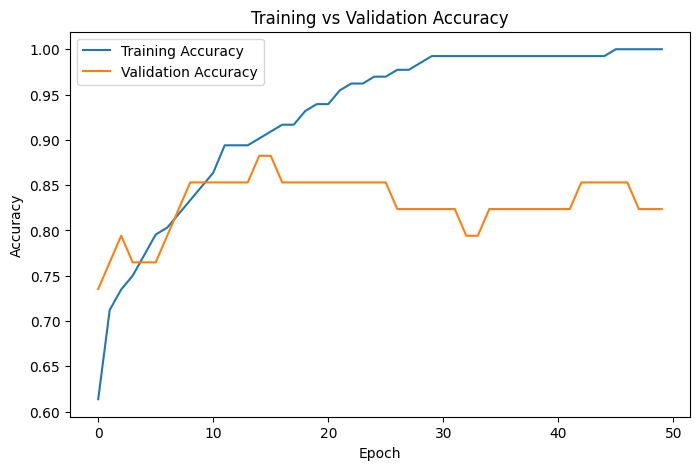

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

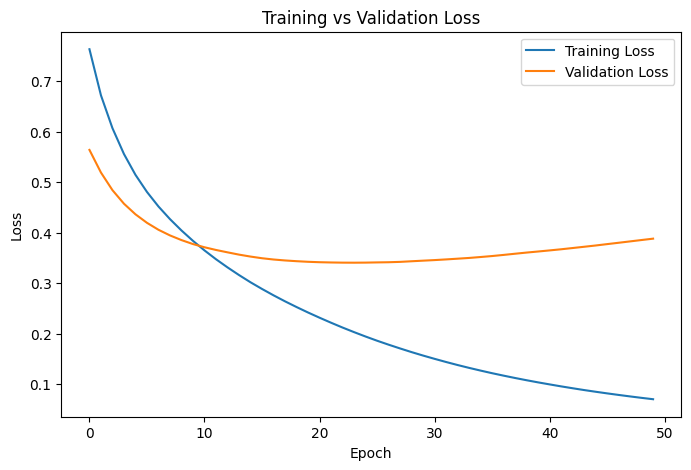

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Predict probabilities
y_pred_probability = basic_model.predict(X_test_scaled)
# Convert probabilities into class labels
y_pred = (y_pred_probability >= 0.5).astype(int).flatten()
print("Predictions:")
print(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predictions:
[1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0
 0 0 0 0 1]


In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Basic ANN Results")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Basic ANN Results
----------------------
Accuracy : 0.9285714285714286
Precision: 0.88
Recall : 1.0
F1 Score : 0.9361702127659575


In [ ]:
# Display classification report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Rock", "Mine"]
))

              precision    recall  f1-score   support

        Rock       1.00      0.85      0.92        20
        Mine       0.88      1.00      0.94        22

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



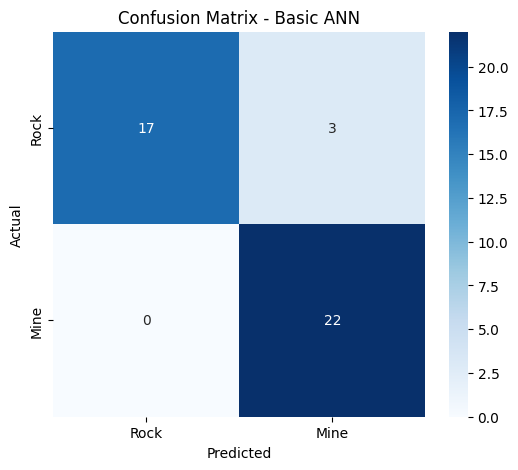

In [ ]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rock", "Mine"],
    yticklabels=["Rock", "Mine"]
)

plt.title("Confusion Matrix - Basic ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Function to create ANN models
def build_ann(
    hidden_layers=1,
    neurons=32,
    activation="relu",
    learning_rate=0.001,
    dropout_rate=0
):
    model = Sequential()

    # First hidden layer
    model.add(
        Dense(
            neurons,
            activation=activation,
            input_shape=(X_train_scaled.shape[1],)
        )
    )
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(
            Dense(
                neurons,
                activation=activation
            )
        )
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
# Different ANN configurations

configurations = [
    {
        "hidden_layers": 1,
        "neurons": 16,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 1,
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 64,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 32,
        "activation": "tanh",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.0005
    }
]
# 23. Run Hyperparameter Experiments
results = []

for config in configurations:

    print("Testing:", config)

    model = build_ann(
        hidden_layers=config["hidden_layers"],
        neurons=config["neurons"],
        activation=config["activation"],
        learning_rate=config["learning_rate"]
    )

    model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.20,
        verbose=0
    )

    # Predictions
    predictions = model.predict(X_test_scaled, verbose=0)

    predictions = (
        predictions >= 0.5
    ).astype(int).flatten()

    # Metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1_value = f1_score(y_test, predictions)

    results.append({
        "Hidden Layers": config["hidden_layers"],
        "Neurons": config["neurons"],
        "Activation": config["activation"],
        "Learning Rate": config["learning_rate"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1_value
    })
# 24. Compare Hyperparameter Results
# Convert results into DataFrame

results_df = pd.DataFrame(results)

# Display results

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

# The model with the highest F1-score can be selected as the tuned model.

# Select the best model configuration

best_config = configurations[
    results_df["F1 Score"].idxmax()
]

print("Best Configuration:")
print(best_config)

Testing: {'hidden_layers': 1, 'neurons': 16, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 1, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 64, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 32, 'activation': 'tanh', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.0005}
Best Configuration:
{'hidden_layers': 1, 'neurons': 16, 'activation': 'relu', 'learning_rate': 0.001}


In [ ]:
# Different ANN configurations

configurations = [
    {
        "hidden_layers": 1,
        "neurons": 16,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 1,
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 64,
        "activation": "relu",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 32,
        "activation": "tanh",
        "learning_rate": 0.001
    },

    {
        "hidden_layers": 2,
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.0005
    }
]

results = []

for config in configurations:

    print("Testing:", config)

    model = build_ann(
        hidden_layers=config["hidden_layers"],
        neurons=config["neurons"],
        activation=config["activation"],
        learning_rate=config["learning_rate"]
    )

    model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.20,
        verbose=0
    )

    # Predictions
    predictions = model.predict(X_test_scaled, verbose=0)

    predictions = (
        predictions >= 0.5
    ).astype(int).flatten()

    # Metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1_value = f1_score(y_test, predictions)

    results.append({
        "Hidden Layers": config["hidden_layers"],
        "Neurons": config["neurons"],
        "Activation": config["activation"],
        "Learning Rate": config["learning_rate"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1_value
    })

Testing: {'hidden_layers': 1, 'neurons': 16, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 1, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 64, 'activation': 'relu', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 32, 'activation': 'tanh', 'learning_rate': 0.001}
Testing: {'hidden_layers': 2, 'neurons': 32, 'activation': 'relu', 'learning_rate': 0.0005}


In [ ]:
# Make predictions
tuned_probability = best_model.predict(
    X_test_scaled
)

tuned_prediction = (
    tuned_probability >= 0.5
).astype(int).flatten()

# Calculate metrics
tuned_accuracy = accuracy_score(
    y_test,
    tuned_prediction
)

tuned_precision = precision_score(
    y_test,
    tuned_prediction
)

tuned_recall = recall_score(
    y_test,
    tuned_prediction
)

tuned_f1 = f1_score(
    y_test, tuned_prediction
)

print("Tuned ANN Results")
print("----------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall :", tuned_recall)
print("F1 Score :", tuned_f1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Tuned ANN Results
----------------------
Accuracy : 0.9047619047619048
Precision: 0.875
Recall : 0.9545454545454546
F1 Score : 0.9130434782608695


In [ ]:
print( classification_report( y_test,
                             tuned_prediction,
                              target_names=["Rock", "Mine"] ) )

              precision    recall  f1-score   support

        Rock       0.94      0.85      0.89        20
        Mine       0.88      0.95      0.91        22

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



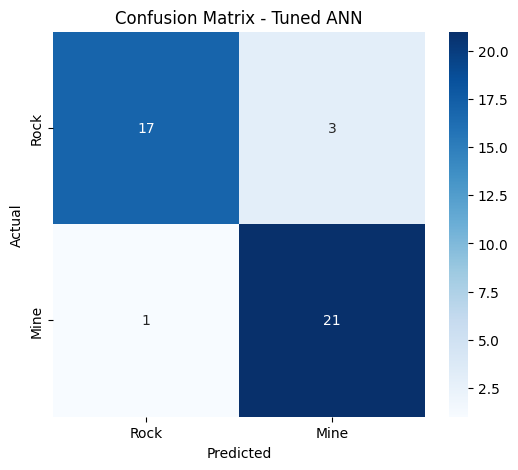

In [ ]:
# Confusion matrix for tuned model
cm_tuned = confusion_matrix(
    y_test, tuned_prediction )
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rock", "Mine"],
    yticklabels=["Rock", "Mine"] )
plt.title("Confusion Matrix - Tuned ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score" ],
    "Basic ANN": [
        accuracy,
        precision,
        recall,
        f1 ],
    "Tuned ANN": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall, tuned_f1 ] })
print(comparison)

      Metric  Basic ANN  Tuned ANN
0   Accuracy   0.928571   0.904762
1  Precision   0.880000   0.875000
2     Recall   1.000000   0.954545
3   F1 Score   0.936170   0.913043


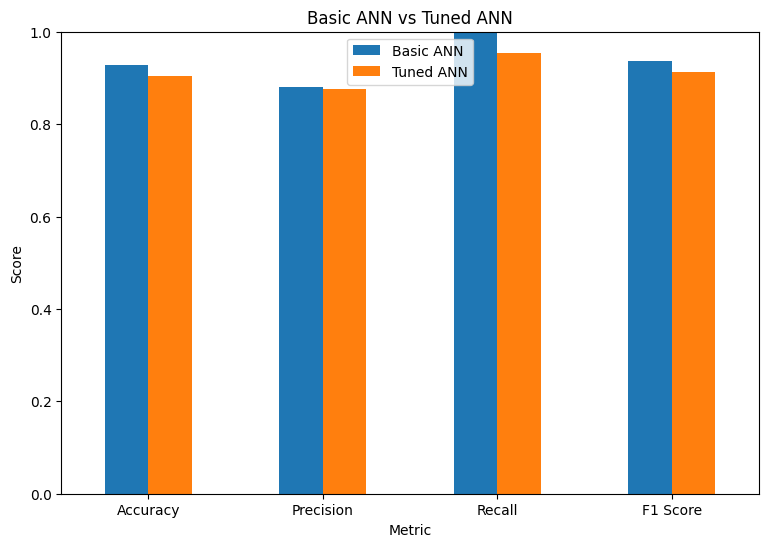

In [ ]:
# Plot model comparison
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(9,6) )
plt.title("Basic ANN vs Tuned ANN")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()